<a href="https://colab.research.google.com/github/gabiuxo/Algoritmos-de-Aprendizaje-Automatico/blob/main/Actividad_2_Regresion_Student_Performance.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Actividad 2 — Modelado predictivo con regresión

**Materia:** Algoritmos de aprendizaje automático  
**Estudiante:** Gabriel Elizondo Martinez
**Fecha:** 22 de agosto de 2026

## Identificación del dataset

- **Nombre:** Student Performance Factors Dataset.
- **Autor indicado en la actividad:** Abdel-Ghany, M. (2025).
- **Fuente original:** Kaggle.
- **Liga de acceso:** https://www.kaggle.com/datasets/mosapabdelghany/student-performance-factors-dataset
- **Fecha de consulta:** 22 de agosto de 2026.
- **Contexto:** el conjunto contiene factores académicos, personales, familiares y escolares relacionados con el desempeño de estudiantes.
- **Unidad de análisis:** cada registro representa a un estudiante y sus características observadas.
- **Variable objetivo:** `Exam_Score`, que representa el puntaje obtenido en el examen.

## Pregunta predictiva

**¿En qué medida las características académicas, personales y escolares de los estudiantes permiten estimar su puntaje de examen mediante modelos de regresión?**

> Para evitar una descarga manual, el archivo se cargará en el entorno temporal de Google Colab desde una copia pública del dataset. La fuente académica que se reporta y cita continúa siendo Kaggle.

## 1. Importación de librerías

In [1]:
# data handling and visualization
import os
import glob
import sys
import subprocess
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# notebook display
from IPython.display import display, Markdown

# preprocessing and modeling
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.inspection import permutation_importance

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 50)
sns.set_theme(style="whitegrid", palette="deep")
RANDOM_STATE = 42

## 2. Carga automática del dataset

Primero se intenta cargar una copia pública del CSV. Si esa dirección no responde, el código utiliza `kagglehub` como respaldo. El archivo vive en la sesión temporal de Colab, por lo que **no es necesario descargarlo manualmente a la computadora**.

In [2]:
# public mirror used only for automatic loading
DATA_URL = "https://raw.githubusercontent.com/hsmanik/Student_performance_factors/main/StudentPerformanceFactors.csv"
KAGGLE_DATASET = "mosapabdelghany/student-performance-factors-dataset"

try:
    df_raw = pd.read_csv(DATA_URL)
    load_method = "public csv mirror"
except Exception:
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q", "kagglehub"],
        check=True
    )
    import kagglehub

    dataset_path = kagglehub.dataset_download(KAGGLE_DATASET)
    csv_files = glob.glob(os.path.join(dataset_path, "**", "*.csv"), recursive=True)
    if not csv_files:
        raise FileNotFoundError("No csv file was found in the Kaggle dataset.")
    df_raw = pd.read_csv(csv_files[0])
    load_method = "kagglehub fallback"

print(f"Load method: {load_method}")
print(f"Dataset shape: {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns")
display(df_raw.head())

Load method: public csv mirror
Dataset shape: 6,607 rows × 20 columns


,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


## 3. Revisión inicial de estructura y calidad

In [3]:
print("Column names:")
print(df_raw.columns.tolist())

print("\nData types and non-null values:")
df_raw.info()

initial_review = pd.DataFrame({
    "Data_type": df_raw.dtypes.astype(str),
    "Missing_values": df_raw.isna().sum(),
    "Unique_values": df_raw.nunique(dropna=True)
})

print(f"\nExact duplicate rows: {df_raw.duplicated().sum()}")
display(initial_review)

Column names:
['Hours_Studied', 'Attendance', 'Parental_Involvement', 'Access_to_Resources', 'Extracurricular_Activities', 'Sleep_Hours', 'Previous_Scores', 'Motivation_Level', 'Internet_Access', 'Tutoring_Sessions', 'Family_Income', 'Teacher_Quality', 'School_Type', 'Peer_Influence', 'Physical_Activity', 'Learning_Disabilities', 'Parental_Education_Level', 'Distance_from_Home', 'Gender', 'Exam_Score']

Data types and non-null values:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Hours_Studied               6607 non-null   int64 
 1   Attendance                  6607 non-null   int64 
 2   Parental_Involvement        6607 non-null   object
 3   Access_to_Resources         6607 non-null   object
 4   Extracurricular_Activities  6607 non-null   object
 5   Sleep_Hours                 6607 non-null   int64 
 6   P

,Data_type,Missing_values,Unique_values
Hours_Studied,int64,0,41
Attendance,int64,0,41
Parental_Involvement,object,0,3
Access_to_Resources,object,0,3
Extracurricular_Activities,object,0,2
Sleep_Hours,int64,0,7
Previous_Scores,int64,0,51
Motivation_Level,object,0,3
Internet_Access,object,0,2
Tutoring_Sessions,int64,0,9


### Limpieza aplicada

- Se estandarizan los nombres de columnas y se eliminan espacios accidentales en categorías.
- `Exam_Score` se convierte explícitamente a tipo numérico.
- Se eliminan duplicados exactos, si existen.
- Solo se eliminan registros sin variable objetivo, porque no pueden utilizarse en regresión supervisada.
- Los valores faltantes de los predictores **no se rellenan todavía**. La imputación se ajustará exclusivamente con el conjunto de entrenamiento dentro del pipeline para evitar fuga de información.
- Los posibles valores extremos de `Exam_Score` se conservan para evaluar cómo afectan los errores del modelo.

In [4]:
df = df_raw.copy()
df.columns = df.columns.str.strip()

object_columns = df.select_dtypes(include="object").columns
for column in object_columns:
    df[column] = df[column].str.strip()

df["Exam_Score"] = pd.to_numeric(df["Exam_Score"], errors="coerce")

rows_before = len(df)
df = df.drop_duplicates()
duplicates_removed = rows_before - len(df)

missing_target_removed = df["Exam_Score"].isna().sum()
df = df.dropna(subset=["Exam_Score"]).reset_index(drop=True)

print(f"Duplicates removed: {duplicates_removed}")
print(f"Rows removed because Exam_Score was missing: {missing_target_removed}")
print(f"Final working shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
display(df.head())

Duplicates removed: 0
Rows removed because Exam_Score was missing: 0
Final working shape: 6,607 rows × 20 columns


,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


## 4. Exploración de la variable objetivo `Exam_Score`

,Exam_Score
count,6607.000000
mean,67.235659
std,3.890456
min,55.000000
25%,65.000000
50%,67.000000
75%,69.000000
max,101.000000


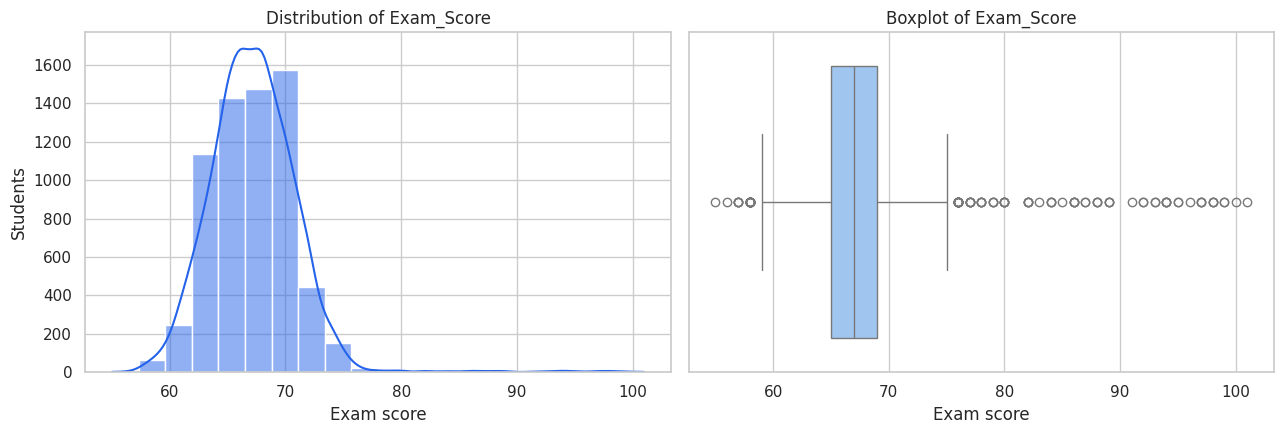

In [5]:
target_summary = df["Exam_Score"].describe().to_frame("Exam_Score")
display(target_summary)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

sns.histplot(df["Exam_Score"], bins=20, kde=True, ax=axes[0], color="#2563EB")
axes[0].set_title("Distribution of Exam_Score")
axes[0].set_xlabel("Exam score")
axes[0].set_ylabel("Students")

sns.boxplot(x=df["Exam_Score"], ax=axes[1], color="#93C5FD")
axes[1].set_title("Boxplot of Exam_Score")
axes[1].set_xlabel("Exam score")

plt.tight_layout()
plt.show()

La distribución se concentra alrededor de los puntajes medios, pero el diagrama de caja permite detectar algunos puntajes altos alejados del resto. No se eliminan automáticamente: podrían ser observaciones válidas y son útiles para comprobar si los modelos presentan dificultades con casos extremos.

## 5. Relación entre predictores numéricos y `Exam_Score`

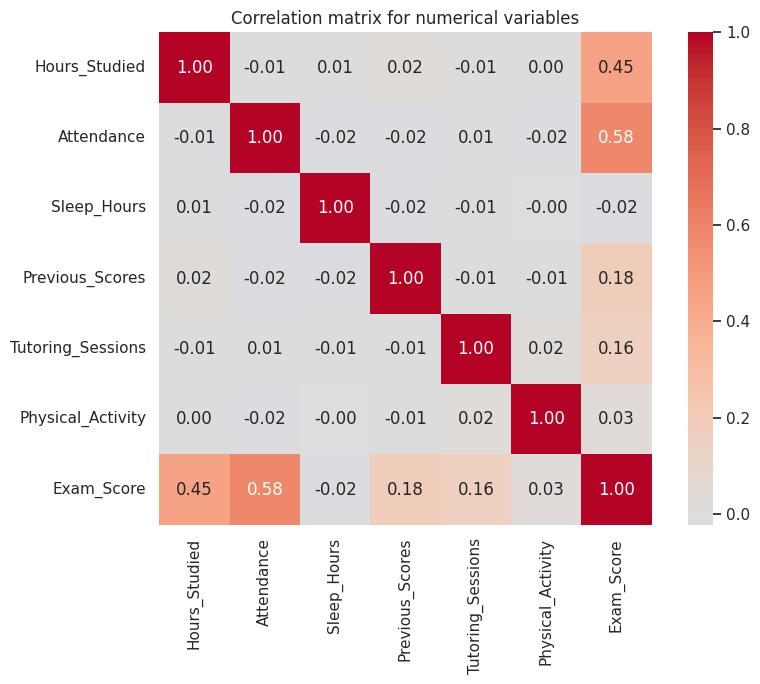

,Correlation_with_Exam_Score
Attendance,0.581072
Hours_Studied,0.445455
Previous_Scores,0.175079
Tutoring_Sessions,0.156525
Physical_Activity,0.027824
Sleep_Hours,-0.017022


In [6]:
numeric_df = df.select_dtypes(include=np.number)
correlation_matrix = numeric_df.corr()

plt.figure(figsize=(9, 7))
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True
)
plt.title("Correlation matrix for numerical variables")
plt.tight_layout()
plt.show()

target_correlations = (
    correlation_matrix["Exam_Score"]
    .drop("Exam_Score")
    .sort_values(key=np.abs, ascending=False)
    .to_frame("Correlation_with_Exam_Score")
)
display(target_correlations)

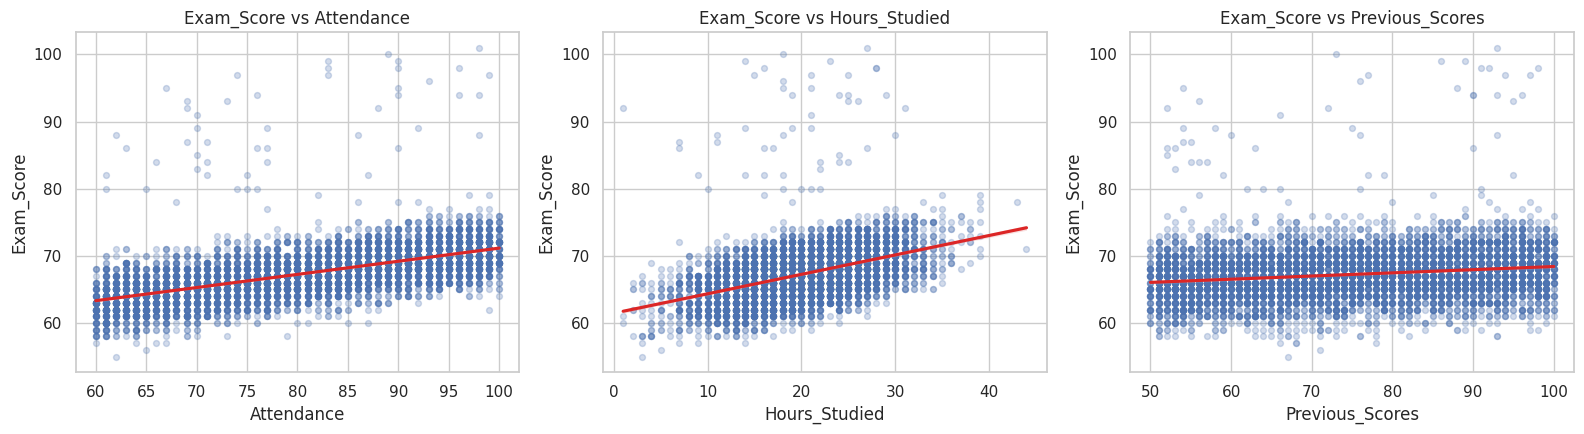

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

for axis, variable in zip(
    axes,
    ["Attendance", "Hours_Studied", "Previous_Scores"]
):
    sns.regplot(
        data=df,
        x=variable,
        y="Exam_Score",
        scatter_kws={"alpha": 0.25, "s": 18},
        line_kws={"color": "#DC2626"},
        ax=axis
    )
    axis.set_title(f"Exam_Score vs {variable}")

plt.tight_layout()
plt.show()

La matriz de correlación y los diagramas de dispersión permiten identificar relaciones lineales. Una correlación positiva indica que, en promedio, ambas variables tienden a aumentar juntas. Esto no demuestra causalidad, pero sí aporta evidencia para seleccionar predictores.

## 6. Relación entre variables categóricas y `Exam_Score`

In [8]:
categorical_columns = df.select_dtypes(include="object").columns.tolist()

category_ranges = []
for column in categorical_columns:
    means = df.groupby(column, dropna=False)["Exam_Score"].mean()
    category_ranges.append({
        "Variable": column,
        "Difference_between_highest_and_lowest_mean": means.max() - means.min()
    })

category_ranges = (
    pd.DataFrame(category_ranges)
    .sort_values("Difference_between_highest_and_lowest_mean", ascending=False)
    .reset_index(drop=True)
)
display(category_ranges)

,Variable,Difference_between_highest_and_lowest_mean
0,Access_to_Resources,1.888801
1,Parental_Involvement,1.734503
2,Distance_from_Home,1.079265
3,Learning_Disabilities,1.078617
4,Parental_Education_Level,1.077304
5,Peer_Influence,1.058929
6,Teacher_Quality,1.035913
7,Family_Income,0.993967
8,Motivation_Level,0.952127
9,Internet_Access,0.757824


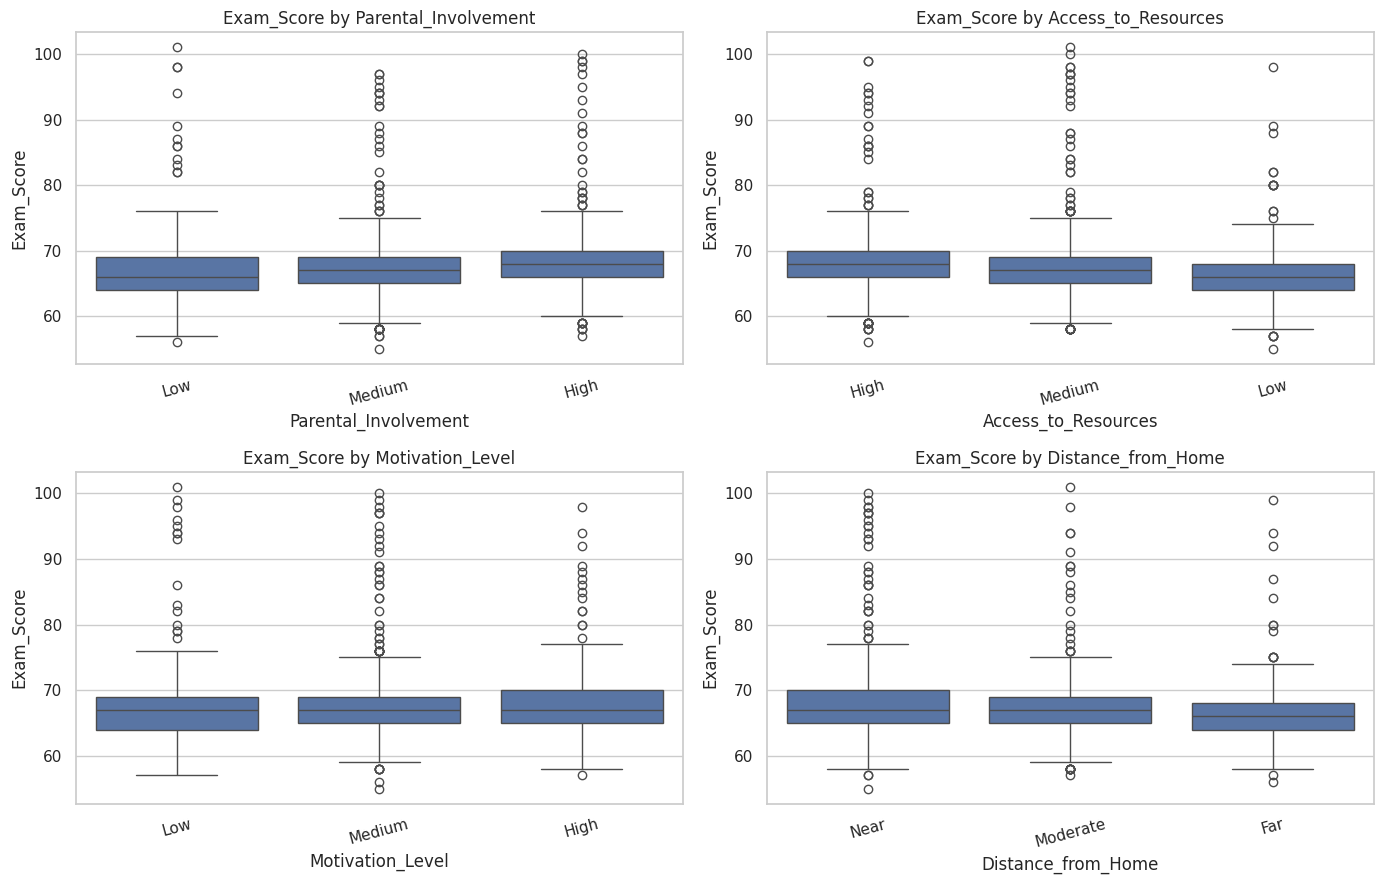

In [9]:
categorical_plots = [
    "Parental_Involvement",
    "Access_to_Resources",
    "Motivation_Level",
    "Distance_from_Home"
]

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

for axis, variable in zip(axes.flatten(), categorical_plots):
    sns.boxplot(data=df, x=variable, y="Exam_Score", ax=axis)
    axis.set_title(f"Exam_Score by {variable}")
    axis.tick_params(axis="x", rotation=15)

plt.tight_layout()
plt.show()

## 7. Selección y justificación de variables

Se conservarán las variables académicas, conductuales, familiares y de acceso que muestran una relación numérica o diferencias observables entre categorías. Entre las variables numéricas, `Attendance`, `Hours_Studied`, `Previous_Scores` y `Tutoring_Sessions` aportan evidencia directa de asociación con el puntaje. Las gráficas categóricas muestran diferencias entre niveles de participación parental, acceso a recursos, motivación, influencia de compañeros y distancia.

Se excluyen:

- `Gender`, porque la diferencia media observada entre sus categorías es prácticamente nula y utilizarla podría introducir un atributo demográfico innecesario.
- `School_Type`, porque la diferencia media observada entre escuela pública y privada también es mínima en este conjunto.

Las variables con relación individual débil, como sueño o actividad física, se conservan porque pueden aportar información complementaria cuando se combinan con otras características. La selección se realiza antes de dividir los datos y no utiliza el conjunto de prueba para ajustar el modelo.

In [10]:
selected_features = [
    "Hours_Studied",
    "Attendance",
    "Parental_Involvement",
    "Access_to_Resources",
    "Extracurricular_Activities",
    "Sleep_Hours",
    "Previous_Scores",
    "Motivation_Level",
    "Internet_Access",
    "Tutoring_Sessions",
    "Family_Income",
    "Teacher_Quality",
    "Peer_Influence",
    "Physical_Activity",
    "Learning_Disabilities",
    "Parental_Education_Level",
    "Distance_from_Home"
]

missing_selected_columns = [c for c in selected_features if c not in df.columns]
if missing_selected_columns:
    raise KeyError(f"Missing expected columns: {missing_selected_columns}")

X = df[selected_features].copy()
y = df["Exam_Score"].copy()

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print("Selected predictors:")
print(selected_features)

X shape: (6607, 17)
y shape: (6607,)
Selected predictors:
['Hours_Studied', 'Attendance', 'Parental_Involvement', 'Access_to_Resources', 'Extracurricular_Activities', 'Sleep_Hours', 'Previous_Scores', 'Motivation_Level', 'Internet_Access', 'Tutoring_Sessions', 'Family_Income', 'Teacher_Quality', 'Peer_Influence', 'Physical_Activity', 'Learning_Disabilities', 'Parental_Education_Level', 'Distance_from_Home']


## 8. División de entrenamiento y prueba

Se utiliza 80 % de los registros para entrenar y 20 % para evaluar. `random_state=42` fija la selección aleatoria, por lo que otra persona podrá repetir el notebook y obtener la misma partición y los mismos resultados. El conjunto de prueba permanecerá sin utilizar durante el ajuste del preprocesamiento y de los modelos.

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE
)

split_summary = pd.DataFrame({
    "Set": ["Training", "Test"],
    "Rows": [len(X_train), len(X_test)],
    "Percentage": [len(X_train) / len(X) * 100, len(X_test) / len(X) * 100]
})
split_summary["Percentage"] = split_summary["Percentage"].round(1).astype(str) + "%"
display(split_summary)

,Set,Rows,Percentage
0,Training,5285,80.0%
1,Test,1322,20.0%


## 9. Pipeline de preprocesamiento reproducible

El `ColumnTransformer` aplica una transformación distinta según el tipo de variable:

- **Numéricas:** imputación con la mediana y estandarización.
- **Ordinales:** imputación con la categoría más frecuente, codificación según su orden lógico y estandarización.
- **Nominales:** imputación con la categoría más frecuente y One-Hot Encoding.

El preprocesamiento está dentro de cada `Pipeline`. Por ello, se ajusta únicamente con `X_train` y evita que información del conjunto de prueba influya en el entrenamiento.

In [12]:
numeric_features = [
    "Hours_Studied",
    "Attendance",
    "Sleep_Hours",
    "Previous_Scores",
    "Tutoring_Sessions",
    "Physical_Activity"
]

ordinal_features = [
    "Parental_Involvement",
    "Access_to_Resources",
    "Motivation_Level",
    "Family_Income",
    "Teacher_Quality",
    "Peer_Influence",
    "Parental_Education_Level",
    "Distance_from_Home"
]

ordinal_categories = [
    ["Low", "Medium", "High"],
    ["Low", "Medium", "High"],
    ["Low", "Medium", "High"],
    ["Low", "Medium", "High"],
    ["Low", "Medium", "High"],
    ["Negative", "Neutral", "Positive"],
    ["High School", "College", "Postgraduate"],
    ["Far", "Moderate", "Near"]
]

nominal_features = [
    "Extracurricular_Activities",
    "Internet_Access",
    "Learning_Disabilities"
]

numeric_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

ordinal_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("ordinal", OrdinalEncoder(
        categories=ordinal_categories,
        handle_unknown="use_encoded_value",
        unknown_value=-1
    )),
    ("scaler", StandardScaler())
])

nominal_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", numeric_pipeline, numeric_features),
        ("ordinal", ordinal_pipeline, ordinal_features),
        ("nominal", nominal_pipeline, nominal_features)
    ],
    verbose_feature_names_out=False
)

print("Preprocessing pipeline created successfully.")

Preprocessing pipeline created successfully.


## 10. Línea base y dos modelos de regresión

- **Línea base:** `DummyRegressor` predice siempre la media de `Exam_Score`. Sirve como referencia mínima.
- **Regresión lineal:** estima una combinación lineal de los predictores.
- **Ridge:** es una regresión lineal con regularización L2. Penaliza coeficientes demasiado grandes y puede ser más estable cuando existen predictores relacionados.

Los tres modelos utilizan exactamente la misma partición de entrenamiento y prueba.

In [13]:
models = {
    "Línea base": Pipeline(steps=[
        ("preprocessor", clone(preprocessor)),
        ("model", DummyRegressor(strategy="mean"))
    ]),
    "Regresión lineal": Pipeline(steps=[
        ("preprocessor", clone(preprocessor)),
        ("model", LinearRegression())
    ]),
    "Ridge": Pipeline(steps=[
        ("preprocessor", clone(preprocessor)),
        ("model", Ridge(alpha=1.0))
    ])
}

predictions = {}

for model_name, model_pipeline in models.items():
    model_pipeline.fit(X_train, y_train)
    predictions[model_name] = model_pipeline.predict(X_test)
    print(f"Trained: {model_name}")

Trained: Línea base
Trained: Regresión lineal
Trained: Ridge


## 11. Evaluación con MAE, RMSE y R²

- **MAE — Mean Absolute Error (error absoluto medio):** indica cuántos puntos se equivoca el modelo en promedio, sin considerar la dirección del error.
- **RMSE — Root Mean Squared Error (raíz del error cuadrático medio):** también se expresa en puntos, pero eleva los errores al cuadrado antes de promediarlos. Por eso penaliza con mayor intensidad los errores grandes.
- **R² — coeficiente de determinación:** indica qué proporción de la variación de `Exam_Score` es explicada por el modelo. Un valor cercano a 1 representa mejor ajuste; 0 equivale aproximadamente a predecir la media y un valor negativo puede ser peor que esa referencia.

Para MAE y RMSE, **menor es mejor**. Para R², **mayor es mejor**.

In [14]:
def evaluate_regression(model_name, y_true, y_pred):
    return {
        "Modelo": model_name,
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R²": r2_score(y_true, y_pred)
    }


results = [
    evaluate_regression(model_name, y_test, y_pred)
    for model_name, y_pred in predictions.items()
]

results_table = pd.DataFrame(results)
display(results_table.round({"MAE": 4, "RMSE": 4, "R²": 4}))

candidate_results = results_table[results_table["Modelo"] != "Línea base"]
best_index = candidate_results["RMSE"].idxmin()
best_model_name = results_table.loc[best_index, "Modelo"]
best_model = models[best_model_name]
best_predictions = predictions[best_model_name]

print(f"Best model according to test RMSE: {best_model_name}")

,Modelo,MAE,RMSE,R²
0,Línea base,2.8235,3.7611,-0.0007
1,Regresión lineal,0.4446,1.7999,0.7708
2,Ridge,0.4446,1.7999,0.7708


Best model according to test RMSE: Ridge


In [15]:
baseline_row = results_table[results_table["Modelo"] == "Línea base"].iloc[0]
best_row = results_table[results_table["Modelo"] == best_model_name].iloc[0]

mae_improvement = baseline_row["MAE"] - best_row["MAE"]
rmse_improvement_pct = (
    (baseline_row["RMSE"] - best_row["RMSE"]) / baseline_row["RMSE"] * 100
)
score_min = y.min()
score_max = y.max()

display(Markdown(f'''
### Interpretación de las métricas

El mejor modelo fue **{best_model_name}**. Su **MAE fue de {best_row['MAE']:.2f} puntos**, por lo que una predicción típica se alejó aproximadamente esa cantidad del puntaje real. En comparación, la línea base presentó un MAE de {baseline_row['MAE']:.2f} puntos; la mejora absoluta fue de **{mae_improvement:.2f} puntos**.

El **RMSE fue de {best_row['RMSE']:.2f} puntos**. Es mayor que el MAE porque algunos casos presentan errores considerablemente más grandes y RMSE les asigna más peso. Frente a la línea base, el RMSE se redujo **{rmse_improvement_pct:.1f} %**.

El **R² fue de {best_row['R²']:.3f}**, lo que indica que el modelo explica aproximadamente **{best_row['R²'] * 100:.1f} %** de la variación observada en `Exam_Score`. Considerando que los puntajes del dataset van de {score_min:.0f} a {score_max:.0f}, el error típico es pequeño respecto al rango total, aunque todavía existen casos extremos que requieren revisión.
'''))


### Interpretación de las métricas

El mejor modelo fue **Ridge**. Su **MAE fue de 0.44 puntos**, por lo que una predicción típica se alejó aproximadamente esa cantidad del puntaje real. En comparación, la línea base presentó un MAE de 2.82 puntos; la mejora absoluta fue de **2.38 puntos**.

El **RMSE fue de 1.80 puntos**. Es mayor que el MAE porque algunos casos presentan errores considerablemente más grandes y RMSE les asigna más peso. Frente a la línea base, el RMSE se redujo **52.1 %**.

El **R² fue de 0.771**, lo que indica que el modelo explica aproximadamente **77.1 %** de la variación observada en `Exam_Score`. Considerando que los puntajes del dataset van de 55 a 101, el error típico es pequeño respecto al rango total, aunque todavía existen casos extremos que requieren revisión.


## 12. Valores reales contra valores predichos

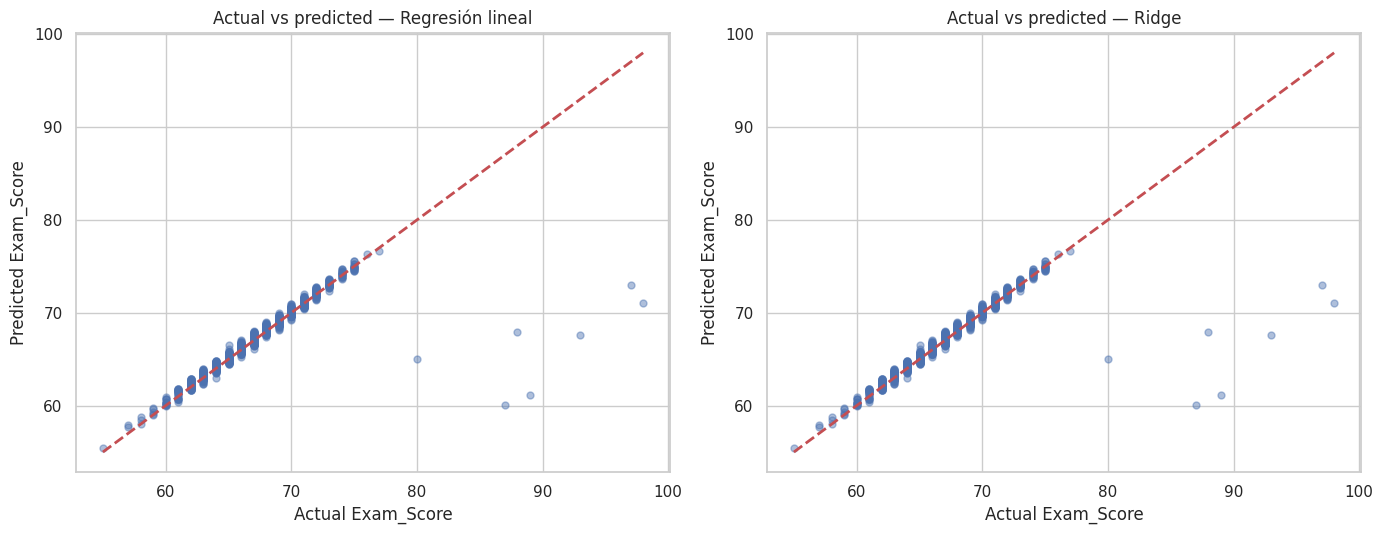

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

for axis, model_name in zip(axes, ["Regresión lineal", "Ridge"]):
    y_pred = predictions[model_name]
    minimum = min(y_test.min(), y_pred.min())
    maximum = max(y_test.max(), y_pred.max())

    axis.scatter(y_test, y_pred, alpha=0.45, s=25)
    axis.plot([minimum, maximum], [minimum, maximum], "r--", linewidth=2)
    axis.set_title(f"Actual vs predicted — {model_name}")
    axis.set_xlabel("Actual Exam_Score")
    axis.set_ylabel("Predicted Exam_Score")

plt.tight_layout()
plt.show()

La línea roja representa una predicción perfecta. Cuanto más cerca se encuentre un punto de esa diagonal, menor es su error. La concentración general alrededor de la línea permite evaluar el ajuste, mientras que los puntos muy alejados muestran observaciones difíciles para el modelo.

## 13. Análisis de residuos del mejor modelo

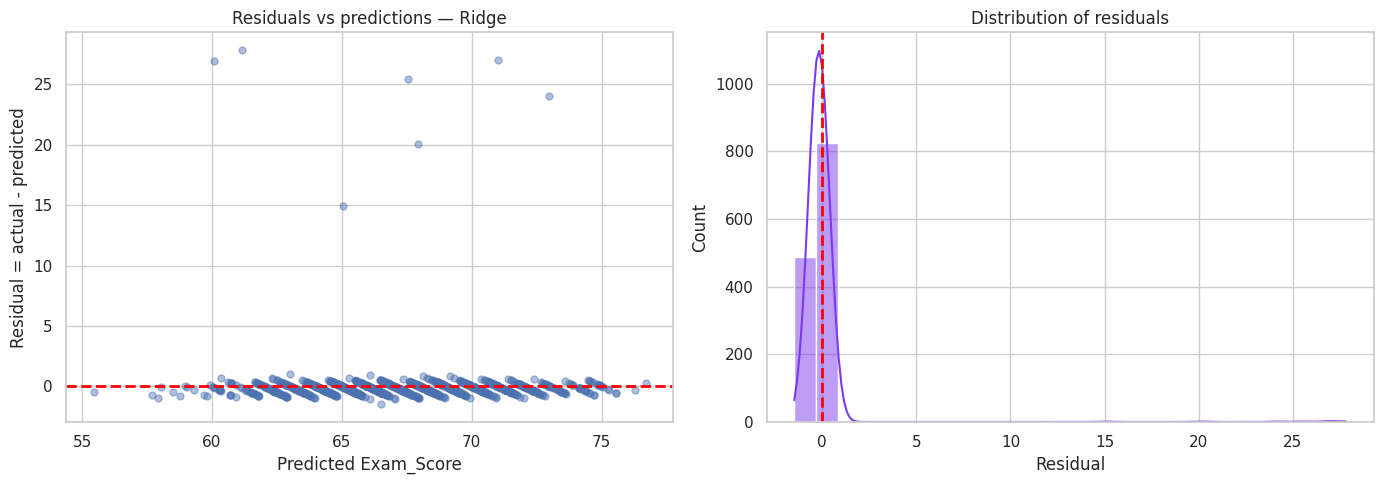

,Residual
count,1322.000000
mean,-0.047238
std,1.799960
min,-1.488196
25%,-0.428257
50%,-0.174105
75%,0.092063
max,27.843714


In [17]:
residuals = y_test.to_numpy() - best_predictions

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(best_predictions, residuals, alpha=0.45, s=25)
axes[0].axhline(0, color="red", linestyle="--", linewidth=2)
axes[0].set_title(f"Residuals vs predictions — {best_model_name}")
axes[0].set_xlabel("Predicted Exam_Score")
axes[0].set_ylabel("Residual = actual - predicted")

sns.histplot(residuals, bins=25, kde=True, ax=axes[1], color="#7C3AED")
axes[1].axvline(0, color="red", linestyle="--", linewidth=2)
axes[1].set_title("Distribution of residuals")
axes[1].set_xlabel("Residual")

plt.tight_layout()
plt.show()

residual_summary = pd.Series(residuals, name="Residual").describe()
display(residual_summary.to_frame())

In [18]:
q1 = y.quantile(0.25)
q3 = y.quantile(0.75)
iqr = q3 - q1
upper_outlier_limit = q3 + 1.5 * iqr
large_residuals = np.sum(np.abs(residuals) > 3)

display(Markdown(f'''
### Interpretación de residuos

La mayoría de los residuos se concentra cerca de cero, lo que indica que el modelo suele producir estimaciones próximas a los valores reales. Sin embargo, existen **{large_residuals} observaciones de prueba con un error absoluto mayor a 3 puntos**. La cola positiva muestra casos en los que el puntaje real fue mucho mayor que el estimado.

El límite superior de valores atípicos calculado con el rango intercuartílico es {upper_outlier_limit:.1f}. Los puntajes altos alejados de la distribución generan residuos grandes y explican por qué RMSE es notablemente mayor que MAE. Esto sugiere que la relación principal es aproximadamente lineal para la mayoría de los estudiantes, pero el modelo no explica bien ciertos resultados extraordinarios.
'''))


### Interpretación de residuos

La mayoría de los residuos se concentra cerca de cero, lo que indica que el modelo suele producir estimaciones próximas a los valores reales. Sin embargo, existen **7 observaciones de prueba con un error absoluto mayor a 3 puntos**. La cola positiva muestra casos en los que el puntaje real fue mucho mayor que el estimado.

El límite superior de valores atípicos calculado con el rango intercuartílico es 75.0. Los puntajes altos alejados de la distribución generan residuos grandes y explican por qué RMSE es notablemente mayor que MAE. Esto sugiere que la relación principal es aproximadamente lineal para la mayoría de los estudiantes, pero el modelo no explica bien ciertos resultados extraordinarios.


## 14. Comparación de observaciones con errores altos y bajos

In [19]:
errors_df = X_test.copy()
errors_df.insert(0, "Exam_Score_actual", y_test)
errors_df.insert(1, "Exam_Score_predicted", best_predictions)
errors_df.insert(2, "Residual", residuals)
errors_df.insert(3, "Absolute_Error", np.abs(residuals))

high_errors = errors_df.nlargest(5, "Absolute_Error")
low_errors = errors_df.nsmallest(5, "Absolute_Error")

columns_to_show = [
    "Exam_Score_actual",
    "Exam_Score_predicted",
    "Absolute_Error",
    "Hours_Studied",
    "Attendance",
    "Previous_Scores",
    "Tutoring_Sessions",
    "Motivation_Level",
    "Access_to_Resources"
]

print("Five observations with the highest absolute errors:")
display(high_errors[columns_to_show].round(2))

print("Five observations with the lowest absolute errors:")
display(low_errors[columns_to_show].round(2))

Five observations with the highest absolute errors:


,Exam_Score_actual,Exam_Score_predicted,Absolute_Error,Hours_Studied,Attendance,Previous_Scores,Tutoring_Sessions,Motivation_Level,Access_to_Resources
217,89,61.16,27.84,19,70,54,0,High,Low
4192,98,71.00,27.00,28,90,91,0,Medium,Medium
2687,87,60.06,26.94,11,71,55,1,Medium,Medium
4531,93,67.56,25.44,26,69,95,0,Low,High
5966,97,72.97,24.03,25,99,77,0,Medium,Medium


Five observations with the lowest absolute errors:


,Exam_Score_actual,Exam_Score_predicted,Absolute_Error,Hours_Studied,Attendance,Previous_Scores,Tutoring_Sessions,Motivation_Level,Access_to_Resources
3916,65,65.0,0.0,19,80,63,1,High,Medium
964,64,64.0,0.0,19,63,56,2,Medium,High
2812,73,73.0,0.0,30,84,72,3,Medium,Medium
676,63,63.0,0.0,13,70,59,0,Medium,Medium
4340,71,71.0,0.0,26,69,90,3,Medium,High


In [20]:
numeric_comparison = pd.DataFrame({
    "High_error_mean": high_errors[numeric_features].mean(),
    "Low_error_mean": low_errors[numeric_features].mean()
})
numeric_comparison["Absolute_difference"] = (
    numeric_comparison["High_error_mean"] - numeric_comparison["Low_error_mean"]
).abs()
numeric_comparison = numeric_comparison.sort_values("Absolute_difference", ascending=False)


def most_common_value(series):
    clean_series = series.dropna()
    if clean_series.empty:
        return "Missing"
    return clean_series.mode().iloc[0]


categorical_comparison = pd.DataFrame({
    "High_error_mode": [most_common_value(high_errors[c]) for c in ordinal_features + nominal_features],
    "Low_error_mode": [most_common_value(low_errors[c]) for c in ordinal_features + nominal_features]
}, index=ordinal_features + nominal_features)
categorical_comparison = categorical_comparison[
    categorical_comparison["High_error_mode"] != categorical_comparison["Low_error_mode"]
]

print("Numerical comparison between error groups:")
display(numeric_comparison.round(2))

print("Categorical modes that differ between error groups:")
display(categorical_comparison)

Numerical comparison between error groups:


,High_error_mean,Low_error_mean,Absolute_difference
Attendance,79.8,73.2,6.6
Previous_Scores,74.4,68.0,6.4
Tutoring_Sessions,0.2,1.8,1.6
Sleep_Hours,7.6,7.0,0.6
Hours_Studied,21.8,21.4,0.4
Physical_Activity,2.6,2.4,0.2


Categorical modes that differ between error groups:


,High_error_mode,Low_error_mode
Parental_Involvement,Low,High
Peer_Influence,Negative,Positive


In [21]:
top_numeric_differences = ", ".join(numeric_comparison.head(3).index.tolist())
different_categories = categorical_comparison.index.tolist()
category_text = ", ".join(different_categories[:4]) if different_categories else "none of the reviewed categories"
high_error_outliers = int((high_errors["Exam_Score_actual"] > upper_outlier_limit).sum())

display(Markdown(f'''
### Interpretación de los casos revisados

Entre los cinco errores más altos, **{high_error_outliers} casos** superan el límite superior de valores atípicos de `Exam_Score`. Las mayores diferencias numéricas entre los grupos aparecen en **{top_numeric_differences}**, mientras que los modos categóricos difieren principalmente en **{category_text}**.

Esta comparación es exploratoria porque utiliza solo cinco casos por grupo. El hallazgo principal es que varios errores altos corresponden a puntajes excepcionalmente elevados que no quedan explicados por la combinación normal de asistencia, horas de estudio y puntajes previos. Esto puede reflejar variables omitidas, observaciones extraordinarias, ruido del dataset o la limitación de una relación lineal. Los casos de bajo error, en cambio, siguen con mayor cercanía el patrón promedio aprendido durante el entrenamiento.
'''))


### Interpretación de los casos revisados

Entre los cinco errores más altos, **5 casos** superan el límite superior de valores atípicos de `Exam_Score`. Las mayores diferencias numéricas entre los grupos aparecen en **Attendance, Previous_Scores, Tutoring_Sessions**, mientras que los modos categóricos difieren principalmente en **Parental_Involvement, Peer_Influence**.

Esta comparación es exploratoria porque utiliza solo cinco casos por grupo. El hallazgo principal es que varios errores altos corresponden a puntajes excepcionalmente elevados que no quedan explicados por la combinación normal de asistencia, horas de estudio y puntajes previos. Esto puede reflejar variables omitidas, observaciones extraordinarias, ruido del dataset o la limitación de una relación lineal. Los casos de bajo error, en cambio, siguen con mayor cercanía el patrón promedio aprendido durante el entrenamiento.


## 15. Validación cruzada k-fold

Se aplica validación cruzada de cinco particiones únicamente sobre el conjunto de entrenamiento. En cada repetición, cuatro particiones se usan para ajustar el pipeline completo y una para validarlo. Como el preprocesamiento permanece dentro del pipeline, la imputación, codificación y estandarización se vuelven a ajustar sin utilizar la partición de validación.

In [22]:
kfold = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cv_negative_rmse = cross_val_score(
    clone(best_model),
    X_train,
    y_train,
    cv=kfold,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

cv_rmse = -cv_negative_rmse
test_rmse = best_row["RMSE"]

cv_results = pd.DataFrame({
    "Fold": np.arange(1, 6),
    "RMSE": cv_rmse
})
display(cv_results.round({"RMSE": 4}))

cv_mean = cv_rmse.mean()
cv_std = cv_rmse.std()

cv_summary = pd.DataFrame({
    "Evaluation": ["Single 80/20 test split", "5-fold cross-validation"],
    "Mean_RMSE": [test_rmse, cv_mean],
    "Standard_deviation": [np.nan, cv_std]
})
display(cv_summary.round({
    "Mean_RMSE": 4,
    "Standard_deviation": 4
}))

,Fold,RMSE
0,1,2.0502
1,2,2.1361
2,3,1.7702
3,4,2.3505
4,5,2.1246


,Evaluation,Mean_RMSE,Standard_deviation
0,Single 80/20 test split,1.7999,NaN
1,5-fold cross-validation,2.0863,0.1871


In [23]:
display(Markdown(f'''
### Interpretación de la validación cruzada

La validación cruzada obtuvo un **RMSE medio de {cv_mean:.2f} puntos** y una **desviación estándar de {cv_std:.2f} puntos**. La evaluación con una sola partición 80/20 produjo un RMSE de {test_rmse:.2f} puntos.

La diferencia entre estos resultados muestra que el desempeño cambia según qué estudiantes formen cada partición. La validación cruzada es una referencia más estable porque evalúa cinco distribuciones distintas de los datos de entrenamiento, en vez de depender de una sola separación aleatoria. Aun así, no sustituye una validación externa con estudiantes provenientes de otra muestra.
'''))


### Interpretación de la validación cruzada

La validación cruzada obtuvo un **RMSE medio de 2.09 puntos** y una **desviación estándar de 0.19 puntos**. La evaluación con una sola partición 80/20 produjo un RMSE de 1.80 puntos.

La diferencia entre estos resultados muestra que el desempeño cambia según qué estudiantes formen cada partición. La validación cruzada es una referencia más estable porque evalúa cinco distribuciones distintas de los datos de entrenamiento, en vez de depender de una sola separación aleatoria. Aun así, no sustituye una validación externa con estudiantes provenientes de otra muestra.


## 16. Relevancia estimada de las variables

,Variable,Importance_mean,Importance_std
1,Attendance,1.9114,0.0299
0,Hours_Studied,1.3041,0.0506
3,Access_to_Resources,0.2476,0.0206
6,Previous_Scores,0.2446,0.0157
2,Parental_Involvement,0.2441,0.0177
9,Tutoring_Sessions,0.1874,0.0137
15,Parental_Education_Level,0.0859,0.0067
10,Family_Income,0.0815,0.0113
7,Motivation_Level,0.0794,0.0104
12,Peer_Influence,0.0767,0.0065


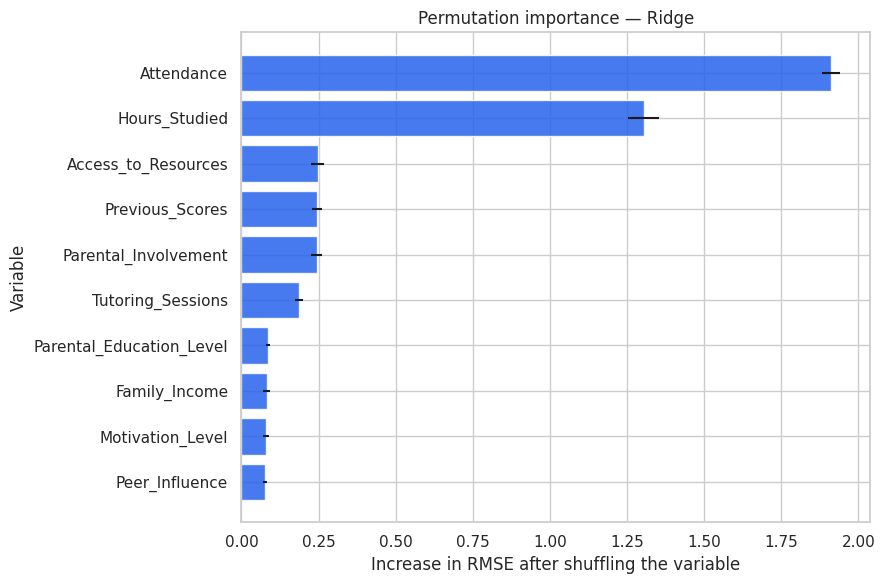

In [24]:
importance = permutation_importance(
    best_model,
    X_test,
    y_test,
    scoring="neg_root_mean_squared_error",
    n_repeats=10,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

importance_df = pd.DataFrame({
    "Variable": X_test.columns,
    "Importance_mean": importance.importances_mean,
    "Importance_std": importance.importances_std
}).sort_values("Importance_mean", ascending=False)

display(importance_df.head(10).round({
    "Importance_mean": 4,
    "Importance_std": 4
}))

plt.figure(figsize=(9, 6))
top_importance = importance_df.head(10).sort_values("Importance_mean")
plt.barh(
    top_importance["Variable"],
    top_importance["Importance_mean"],
    xerr=top_importance["Importance_std"],
    color="#2563EB",
    alpha=0.85
)
plt.title(f"Permutation importance — {best_model_name}")
plt.xlabel("Increase in RMSE after shuffling the variable")
plt.ylabel("Variable")
plt.tight_layout()
plt.show()

La importancia por permutación mide cuánto empeora el modelo cuando los valores de una variable se mezclan al azar. Si el RMSE aumenta de forma clara, el modelo dependía de esa variable. Esta medida describe utilidad predictiva dentro de este dataset; no demuestra que la variable cause el resultado académico.

## 17. Generación del archivo CSV procesado

In [25]:
# transform all rows with the preprocessor fitted only on training data
processed_matrix = best_model.named_steps["preprocessor"].transform(X)
processed_feature_names = best_model.named_steps["preprocessor"].get_feature_names_out()

if hasattr(processed_matrix, "toarray"):
    processed_matrix = processed_matrix.toarray()

processed_df = pd.DataFrame(processed_matrix, columns=processed_feature_names)
processed_df["Exam_Score"] = y.to_numpy()

processed_csv_name = "student_performance_processed.csv"
processed_df.to_csv(processed_csv_name, index=False)

print(f"Saved file: {processed_csv_name}")
print(f"Processed shape: {processed_df.shape[0]:,} rows × {processed_df.shape[1]} columns")
print(f"Total missing values: {processed_df.isna().sum().sum()}")
display(processed_df.head())

Saved file: student_performance_processed.csv
Processed shape: 6,607 rows × 21 columns
Total missing values: 0


,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Parental_Involvement,Access_to_Resources,Motivation_Level,Family_Income,Teacher_Quality,Peer_Influence,Parental_Education_Level,Distance_from_Home,Extracurricular_Activities_No,Extracurricular_Activities_Yes,Internet_Access_No,Internet_Access_Yes,Learning_Disabilities_No,Learning_Disabilities_Yes,Exam_Score
0,0.506102,0.358254,-0.016740,-0.143082,-1.215819,0.030381,-1.561144,1.29316,-1.299270,-1.057637,-0.333519,1.055654,-0.890783,0.753634,1.0,0.0,0.0,1.0,1.0,0.0,67
1,-0.161375,-1.378148,0.669094,-1.114955,0.405784,0.997645,-1.561144,-0.14052,-1.299270,0.289257,-0.333519,-1.576632,0.392692,-0.733098,1.0,0.0,0.0,1.0,1.0,0.0,61
2,0.672971,1.573735,-0.016740,1.106469,0.405784,0.997645,-0.123248,-0.14052,0.141486,0.289257,-0.333519,-0.260489,1.676168,0.753634,0.0,1.0,0.0,1.0,1.0,0.0,74
3,1.507317,0.792355,0.669094,1.592406,-0.405017,0.997645,-1.561144,-0.14052,0.141486,0.289257,-0.333519,-1.576632,-0.890783,-0.733098,0.0,1.0,0.0,1.0,1.0,0.0,71
4,-0.161375,1.052815,-0.702575,-0.698438,1.216586,0.997645,-0.123248,-0.14052,0.141486,0.289257,1.345194,-0.260489,0.392692,0.753634,0.0,1.0,0.0,1.0,1.0,0.0,70


El CSV anterior queda listo para adjuntarse como archivo procesado. Contiene las variables numéricas imputadas y estandarizadas, las variables ordinales codificadas, las variables nominales convertidas mediante One-Hot Encoding y la variable objetivo original.

##Conclusión
El modelo con mejor desempeño fue Ridge, con un MAE de 0.44 puntos, un RMSE de 1.80 puntos y un R² de 0.771 en el conjunto de prueba. En comparación con la línea base, redujo el RMSE en 52.1 %, por lo que sí aporta una mejora sustancial frente a predecir siempre la media.

Según la importancia por permutación, las variables con mayor aporte predictivo fueron Attendance, Hours_Studied, Access_to_Resources, Previous_Scores, Parental_Involvement. Esto coincide con la exploración inicial, en la que la asistencia y las horas de estudio presentaron relaciones claras con Exam_Score.

La validación cruzada de cinco particiones obtuvo un RMSE medio de 2.09 ± 0.19 puntos. Esta variación indica que el desempeño depende parcialmente de la composición de la muestra, aunque el resultado general se mantiene mejor que la línea base.

La principal limitación aparece en estudiantes con puntajes excepcionalmente altos: los modelos lineales tienden a subestimarlos y producen residuos grandes. Además, el análisis no demuestra causalidad, puede omitir factores relevantes y no confirma que la muestra represente a otras poblaciones estudiantiles. Como siguiente mejora se propone probar un modelo no lineal con ajuste de hiperparámetros y validarlo con datos externos.

En conclusión, el modelo es suficiente como primera aproximación académica, pero requiere mayor validación, revisión de valores extremos y evaluación de equidad antes de utilizarse para apoyar decisiones sobre estudiantes reales.